In [1]:
import pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter
from datetime import datetime, timezone

# import binance files
from binance.binance_funding import build_binance_funding_df, build_binance_basis_df
from binance.binance_candles import build_binance_candles_df
from binance.binance_oi import build_binance_oi_df
from binance.binance_liquidation import build_binance_liquidation_df
from binance.binance_long_short import build_binance_global_account_long_short_df, build_binance_top_account_long_short_df

# import hyperliquid files
from hyperliquid.hl_candles import build_hl_candles_df
from hyperliquid.hl_funding import build_hl_funding_df, build_hl_8h_funding_df
from hyperliquid.hl_oi import build_hl_oi_df
from hyperliquid.hl_liquidation import build_hl_liquidation_df

In [2]:
# token info
token_name_binance = "BTCUSDT" # Binance API token name
token_name_hl = "BTC" # HL API token name
cg_token_name_binance = "BTCUSD_PERP" # CoinGlass API Binance token name
cg_token_name_hl = "BTC-USD" # CoinGlass API HL token name
contract_type = "PERPETUAL"
interval = "4h"
start_time = datetime(2026, 1, 15, 0, 0, 0, tzinfo=timezone.utc) # start date: jan 15th
end_time = datetime(2026, 2, 10, 0, 0, 0, tzinfo=timezone.utc) # end date: feb 10th
limit = 1000

# convert time to unix format
start_time_stamp = int(start_time.timestamp() * 1000)
end_time_stamp = int(end_time.timestamp() * 1000)

In [3]:
# hyperliquid dataframes
hl_candles_df = build_hl_candles_df(token_name_hl, start_time_stamp, end_time_stamp, interval) # candles
hl_funding_df = build_hl_funding_df(token_name_hl, start_time_stamp, end_time_stamp) # funding rate
hl_8h_funding_df = build_hl_8h_funding_df(hl_funding_df) # funding with 8h interval
hl_oi_df = build_hl_oi_df(cg_token_name_hl, interval, start_time_stamp, end_time_stamp) # open interest
hl_liquidation_df = build_hl_liquidation_df(cg_token_name_hl, interval, start_time_stamp, end_time_stamp) # liquidation

In [4]:
# binance dataframes
binance_candles_df = build_binance_candles_df(token_name_binance, interval, start_time_stamp, end_time_stamp, limit) # candles
binance_funding_df = build_binance_funding_df(token_name_binance, start_time_stamp, end_time_stamp, limit) # funding rate
binance_basis_df = build_binance_basis_df(token_name_binance, contract_type, interval, limit, start_time_stamp, end_time_stamp) # basis
binance_oi_df = build_binance_oi_df(cg_token_name_binance, interval, start_time_stamp, end_time_stamp) # open interest
binance_global_account_long_short_df = build_binance_global_account_long_short_df(cg_token_name_binance, interval, start_time_stamp, end_time_stamp) # global account long/short
binance_top_account_long_short_df = build_binance_top_account_long_short_df(cg_token_name_binance, interval, start_time_stamp, end_time_stamp) # top account long/short
binance_liquidation_df = build_binance_liquidation_df(cg_token_name_binance, interval, start_time_stamp, end_time_stamp) # liquidation

In [5]:
# compute hyperliquid typical price and notional volume
hl_candles_df["typical_price"] = (hl_candles_df["high"] + hl_candles_df["low"] + hl_candles_df["close"]) / 3
hl_candles_df["notional_volume"] = hl_candles_df["typical_price"] * hl_candles_df["volume"]

In [ ]:
# compute hyperliquid volume multiplier
def hype_volume_multiplier(hl_candles_df: pd.DataFrame):

    # filter df between jan. 15th and jan. 29th
    df_jan15_jan29 = hl_candles_df[
        (hl_candles_df["start_time"] >= pd.Timestamp("2026-01-15")) &
        (hl_candles_df["start_time"] <= pd.Timestamp("2026-01-29"))
    ]

    # filter df between jan. 29th and feb. 07th
    df_jan29_feb07 = hl_candles_df[
        (hl_candles_df["start_time"] >= pd.Timestamp("2026-01-29")) &
        (hl_candles_df["start_time"] <= pd.Timestamp("2026-02-07"))
    ]

    # compute volume multiplier
    avg_vlm_jan15_jan29 = df_jan15_jan29["notional_volume"].mean()
    avg_vlm_jan29_feb07 = df_jan29_feb07["notional_volume"].mean()
    volume_multiplier = avg_vlm_jan29_feb07 / avg_vlm_jan15_jan29
    return volume_multiplier

print(hype_volume_multiplier(hl_candles_df))

In [ ]:
# plot price and notional volume
def plot_price_volume(hl_candles_df: pd.DataFrame, binance_candles_df: pd.DataFrame):

    fig, ax1 = plt.subplots(figsize = (14, 7))
    ax2 = ax1.twinx()

    ax1.plot(hl_candles_df["start_time"], hl_candles_df["typical_price"], color = "#A900B8", label = "Price")
    ax2.plot(hl_candles_df["start_time"], hl_candles_df["notional_volume"], color = "#00B8A9", label = "Hyperliquid")
    ax2.plot(binance_candles_df["start_time"], binance_candles_df["notional_volume"], color = "#F0B90A", label = "Binance")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Price (USD)")
    ax2.set_ylabel("Notional Volume (USD)")

    # formatting
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    fig.autofmt_xdate()
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e9:.1f}B"))

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
    handles1 + handles2,
    labels1 + labels2
    )
    plt.title("BTC Perps Notional Volume vs. Time")

plot_price_volume(hl_candles_df, binance_candles_df)

In [ ]:
# plot funding (note: 8h intervals)
def plot_funding(hl_8h_funding_df: pd.DataFrame, binance_funding_df: pd.DataFrame):

    fig, ax = plt.subplots(figsize = (14, 7))
    ax.plot(binance_funding_df["fundingTime"], binance_funding_df["fundingRate"], color = "#F0B90A", label = "Binance")
    ax.plot(hl_8h_funding_df["time"], hl_8h_funding_df["fundingRate"], color = "#00B8A9", label = "Hyperliquid")
    ax.set_xlabel("Time")
    ax.set_ylabel("Funding Rate")

    # formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    fig.autofmt_xdate()
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: f"{y*100:.3f}%")
    )
    ax.legend()
    plt.title("BTC Perps: Funding")

plot_funding(hl_8h_funding_df, binance_funding_df)

In [ ]:
# compute exact basis rate for binance
binance_basis_df["basisRate_exact"] = (binance_basis_df["futuresPrice"] - binance_basis_df["indexPrice"]) / binance_basis_df["futuresPrice"]

In [ ]:
# plot basis
def plot_basis(hl_funding_df: pd.DataFrame):

    fig, ax = plt.subplots(figsize = (14, 7))
    ax.plot(hl_funding_df["time"], hl_funding_df["premium"], color = "#00B8A9", label = "Hyperliquid")
    ax.plot(binance_basis_df["timestamp"], binance_basis_df["basisRate_exact"], color = "#F0B90A", label = "Binance")
    ax.set_xlabel("Time")
    ax.set_ylabel("Basis")

    # formatting
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    fig.autofmt_xdate()
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    plt.title("BTC Perps: Basis")

plot_basis(hl_funding_df)

In [ ]:
# plot open interest
def plot_oi(hl_oi_df: pd.DataFrame, binance_oi_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize = (14, 7))
    ax.plot(hl_oi_df["time"], hl_oi_df["close"], color = "#00B8A9", label = "Hyperliquid")
    ax.plot(binance_oi_df["time"], binance_oi_df["close"], color = "#F0B90A", label = "Binance")
    ax.set_xlabel("Time")
    ax.set_ylabel("Open Interest (USD)")

    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x / 1e9:.1f}B"))
    fig.autofmt_xdate()
    plt.title("BTC Perps: Open Interest")

plot_oi(hl_oi_df, binance_oi_df)

In [18]:
# compute turnover (volume / open interest)

binance_turnover_df = pd.DataFrame({"end_time": binance_candles_df["end_time"], "turnover": binance_candles_df["notional_volume"] / binance_oi_df["close"]})
binance_turnover_df["rolling_turnover"] = binance_turnover_df["turnover"].rolling(6).mean() # add rolling turnover

hl_turnover_df = pd.DataFrame({"end_time": hl_candles_df["end_time"], "turnover": hl_candles_df["notional_volume"] / hl_oi_df["close"]})
hl_turnover_df["rolling_turnover"] = hl_turnover_df["turnover"].rolling(6).mean() # add rolling tunrover

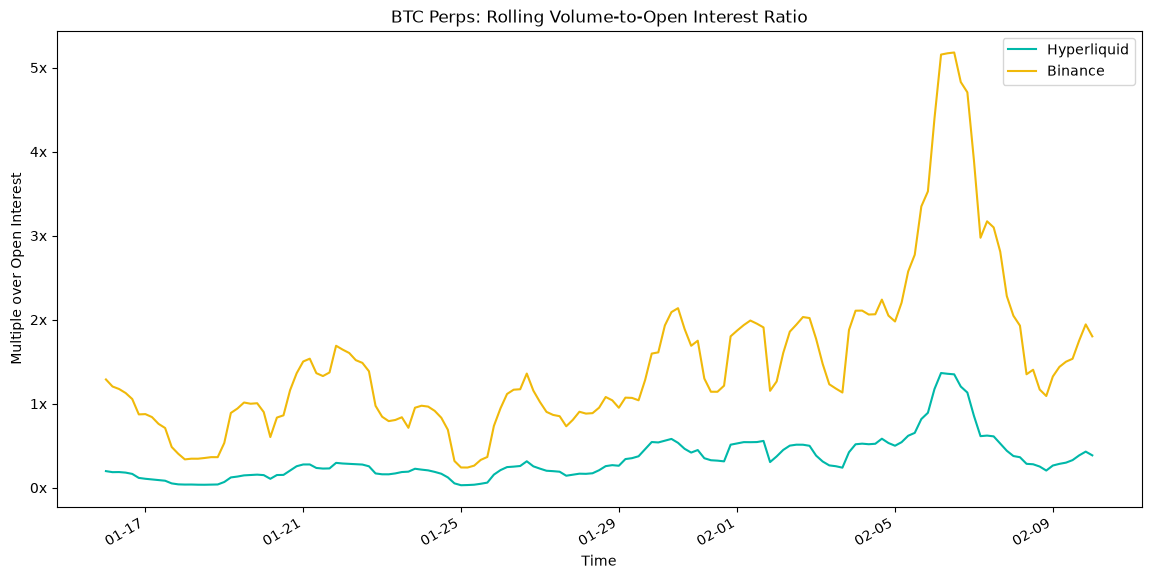

In [30]:
# plot turnover
def plot_turnover(hl_turnover_df: pd.DataFrame, binance_turnover_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize = (14, 7))
    ax.plot(hl_turnover_df["end_time"], hl_turnover_df["rolling_turnover"], color = "#00B8A9", label = "Hyperliquid")
    ax.plot(binance_turnover_df["end_time"], binance_turnover_df["rolling_turnover"], color = "#F0B90A", label = "Binance")
    ax.set_xlabel("Time")
    ax.set_ylabel("Multiple over Open Interest")

    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0f}x"))
    fig.autofmt_xdate()
    plt.title("BTC Perps: Rolling Volume-to-Open Interest Ratio")


plot_turnover(hl_turnover_df, binance_turnover_df)

In [23]:
# compute liquidation intensity
hl_liquidation_df["intensity"] = hl_liquidation_df["long_liquidation_usd"] / hl_oi_df["close"]
binance_liquidation_df["intensity"] = binance_liquidation_df["long_liquidation_usd"] / binance_oi_df["close"]

In [37]:
binance_liquidation_df["intensity"].max() * 100
hl_liquidation_df["intensity"].max() * 100

np.float64(13.260172507867992)

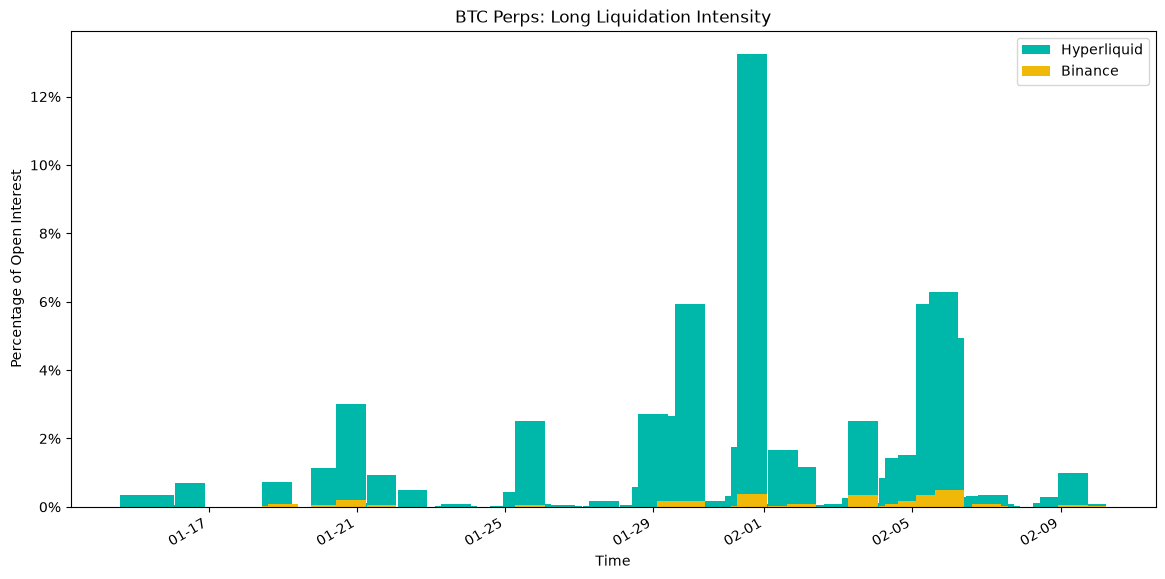

In [27]:
# plot liquidation intensity
def plot_liquidation(hl_liquidation_df: pd.DataFrame, binance_liquidation_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize = (14, 7))
    ax.bar(hl_liquidation_df["time"], hl_liquidation_df["intensity"], color = "#00B8A9", label = "Hyperliquid")
    ax.bar(binance_liquidation_df["time"], binance_liquidation_df["intensity"], color = "#F0B90A", label = "Binance")
    ax.set_xlabel("Time")
    ax.set_ylabel("Percentage of Open Interest")

    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y * 100:.0f}%"))
    fig.autofmt_xdate()
    plt.title("BTC Perps: Long Liquidation Intensity")

plot_liquidation(hl_liquidation_df, binance_liquidation_df)

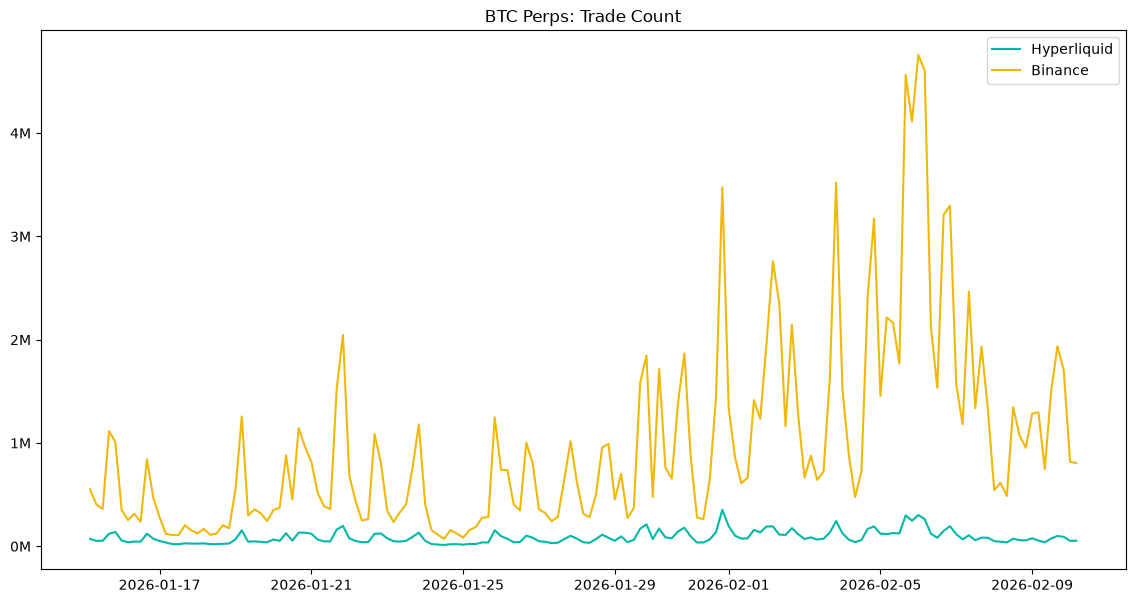

In [16]:
fig, ax = plt.subplots(figsize = (14, 7))
ax.plot(hl_candles_df["end_time"], hl_candles_df["trade_count"], color = "#00B8A9", label = "Hyperliquid")
ax.plot(binance_candles_df["end_time"], binance_candles_df["trade_count"], color = "#F0B90A", label = "Binance")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x / 1e6:.0f}M"))
ax.legend()
plt.title("BTC Perps: Trade Count")
plt.show()

In [32]:
hl_candles_df["trade_count"].sum(), binance_candles_df["trade_count"].sum()

(np.int64(13830514), np.int64(156075937))